# Análise Comparativa: AUs vs Blendshapes — Evolução Temporal
- Participante 82553: tem vídeos com A/H e sem A/H
- Participante 82609: todos os vídeos sem A/H
- Sliding window + suavização com média móvel

In [1]:
# CÉLULA 1: Imports e configuração
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings('ignore')

#DIRECTORY_VARIABLES NEED TO CHANGE TO YOUR CORRECT DIRECTORIES
BASE_DIR = r'\ABAW\data'

AU_DIR = os.path.join(BASE_DIR, 'au_features')
BS_DIR = os.path.join(BASE_DIR, 'blendshape_features')

# Carregar labels
df = pd.read_csv(os.path.join(BASE_DIR, 'bah-video.csv'))
df['participant_id'] = df['video-path'].str.split('/').str[1]
df['video_name'] = df['video-path'].str.split('/').str[-1].str.replace('.mp4', '', regex=False)

# Parâmetros de visualização
ORIGINAL_FPS = 30
SAMPLE_RATE = 3
EFFECTIVE_FPS = ORIGINAL_FPS / SAMPLE_RATE  # ~10fps
SMOOTH_WINDOW = 10  # média móvel de 10 amostras (~1s a 10fps)

# Nomes dos blendshapes do MediaPipe (os mais relevantes pra emoção)
# Vamos carregar os nomes do primeiro arquivo
BS_NAMES_FULL = [
    '_neutral', 'browDownLeft', 'browDownRight', 'browInnerUp', 'browOuterUpLeft',
    'browOuterUpRight', 'cheekPuff', 'cheekSquintLeft', 'cheekSquintRight',
    'eyeBlinkLeft', 'eyeBlinkRight', 'eyeLookDownLeft', 'eyeLookDownRight',
    'eyeLookInLeft', 'eyeLookInRight', 'eyeLookOutLeft', 'eyeLookOutRight',
    'eyeLookUpLeft', 'eyeLookUpRight', 'eyeSquintLeft', 'eyeSquintRight',
    'eyeWideLeft', 'eyeWideRight', 'jawForward', 'jawLeft', 'jawOpen',
    'jawRight', 'mouthClose', 'mouthDimpleLeft', 'mouthDimpleRight',
    'mouthFrownLeft', 'mouthFrownRight', 'mouthFunnel', 'mouthLeft',
    'mouthLowerDownLeft', 'mouthLowerDownRight', 'mouthPressLeft',
    'mouthPressRight', 'mouthPucker', 'mouthRight', 'mouthRollLower',
    'mouthRollUpper', 'mouthShrugLower', 'mouthShrugUpper', 'mouthSmileLeft',
    'mouthSmileRight', 'mouthStretchLeft', 'mouthStretchRight', 'mouthUpperUpLeft',
    'mouthUpperUpRight', 'noseSneerLeft', 'noseSneerRight'
]

AU_NAMES = [
    'AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10',
    'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24',
    'AU25', 'AU26', 'AU28', 'AU43'
]

print(f"Effective FPS: {EFFECTIVE_FPS}")
print(f"Smooth window: {SMOOTH_WINDOW} amostras ({SMOOTH_WINDOW/EFFECTIVE_FPS:.1f}s)")
print(f"AUs: {len(AU_NAMES)} | Blendshapes: {len(BS_NAMES_FULL)}")

Effective FPS: 10.0
Smooth window: 10 amostras (1.0s)
AUs: 20 | Blendshapes: 52


In [7]:
# DIAGNÓSTICO: ver como estão os nomes
pid = '82553'

# Nomes no CSV
csv_names = df[df['participant_id'] == pid]['video_name'].tolist()
print("CSV (primeiros 3):")
for n in csv_names[:3]:
    print(f"  '{n}'")

# Nomes dos .npy de AU
au_files = os.listdir(os.path.join(AU_DIR, pid))
print("\nAU .npy (primeiros 3):")
for n in au_files[:3]:
    print(f"  '{n}'")

# Nomes dos .npy de BS
bs_files = os.listdir(os.path.join(BS_DIR, pid))
print("\nBS .npy (primeiros 3):")
for n in bs_files[:3]:
    print(f"  '{n}'")

CSV (primeiros 3):
  '82553_Question_5_2024-08-22_12-12-54_Video'
  '82553_Question_2_2024-08-22_12-17-23_Video'
  '82553_Question_1_2024-08-22_12-11-55_Video'

AU .npy (primeiros 3):
  '82553_Question_1_2024-08-22_12-11-55_Video.mp4.npy'
  '82553_Question_2_2024-08-22_12-17-23_Video.mp4.npy'
  '82553_Question_3_2024-08-22_12-19-41_Video.mp4.npy'

BS .npy (primeiros 3):
  '82553_Question_1_2024-08-22_12-11-55_Video.mp4.npy'
  '82553_Question_2_2024-08-22_12-17-23_Video.mp4.npy'
  '82553_Question_3_2024-08-22_12-19-41_Video.mp4.npy'


In [8]:
# CÉLULA 2: Carregar dados dos 2 participantes (CORRIGIDA)

target_pids = ['82553', '82609']

data = {}

for pid in target_pids:
    data[pid] = {}
    pid_videos = df[df['participant_id'] == pid]

    for _, row in pid_videos.iterrows():
        vname = row['video_name']  # sem .mp4
        label = row['label']

        # Os .npy foram salvos com .mp4 no nome
        au_path = os.path.join(AU_DIR, pid, f"{vname}.mp4.npy")
        if not os.path.exists(au_path):
            au_path = os.path.join(AU_DIR, pid, f"{vname}.npy")
            if not os.path.exists(au_path):
                continue

        bs_path = os.path.join(BS_DIR, pid, f"{vname}.mp4.npy")
        if not os.path.exists(bs_path):
            bs_path = os.path.join(BS_DIR, pid, f"{vname}.npy")
            if not os.path.exists(bs_path):
                continue

        au = np.load(au_path).astype(np.float64)
        au = np.nan_to_num(au, nan=0.0)
        bs = np.load(bs_path).astype(np.float64)

        min_len = min(len(au), len(bs))
        au = au[:min_len]
        bs = bs[:min_len]

        q_num = vname.split('Question_')[1][0]
        data[pid][vname] = {'au': au, 'bs': bs, 'label': label, 'q': q_num}

for pid in target_pids:
    print(f"\n=== Participante {pid} ===")
    for vname, d in data[pid].items():
        duration = len(d['au']) / EFFECTIVE_FPS
        print(f"  Q{d['q']} | AH={d['label']} | {len(d['au'])} frames ({duration:.1f}s) | "
              f"AU shape={d['au'].shape} | BS shape={d['bs'].shape}")


=== Participante 82553 ===
  Q5 | AH=0 | 83 frames (8.3s) | AU shape=(83, 20) | BS shape=(83, 52)
  Q2 | AH=1 | 141 frames (14.1s) | AU shape=(141, 20) | BS shape=(141, 52)
  Q1 | AH=1 | 140 frames (14.0s) | AU shape=(140, 20) | BS shape=(140, 52)
  Q7 | AH=1 | 117 frames (11.7s) | AU shape=(117, 20) | BS shape=(117, 52)
  Q3 | AH=0 | 116 frames (11.6s) | AU shape=(116, 20) | BS shape=(116, 52)
  Q6 | AH=1 | 159 frames (15.9s) | AU shape=(159, 20) | BS shape=(159, 52)
  Q4 | AH=1 | 123 frames (12.3s) | AU shape=(123, 20) | BS shape=(123, 52)

=== Participante 82609 ===
  Q1 | AH=0 | 69 frames (6.9s) | AU shape=(69, 20) | BS shape=(69, 52)
  Q3 | AH=0 | 112 frames (11.2s) | AU shape=(112, 20) | BS shape=(112, 52)
  Q5 | AH=0 | 78 frames (7.8s) | AU shape=(78, 20) | BS shape=(78, 52)
  Q7 | AH=0 | 110 frames (11.0s) | AU shape=(110, 20) | BS shape=(110, 52)
  Q2 | AH=0 | 88 frames (8.8s) | AU shape=(88, 20) | BS shape=(88, 52)
  Q4 | AH=0 | 91 frames (9.1s) | AU shape=(91, 20) | BS shap

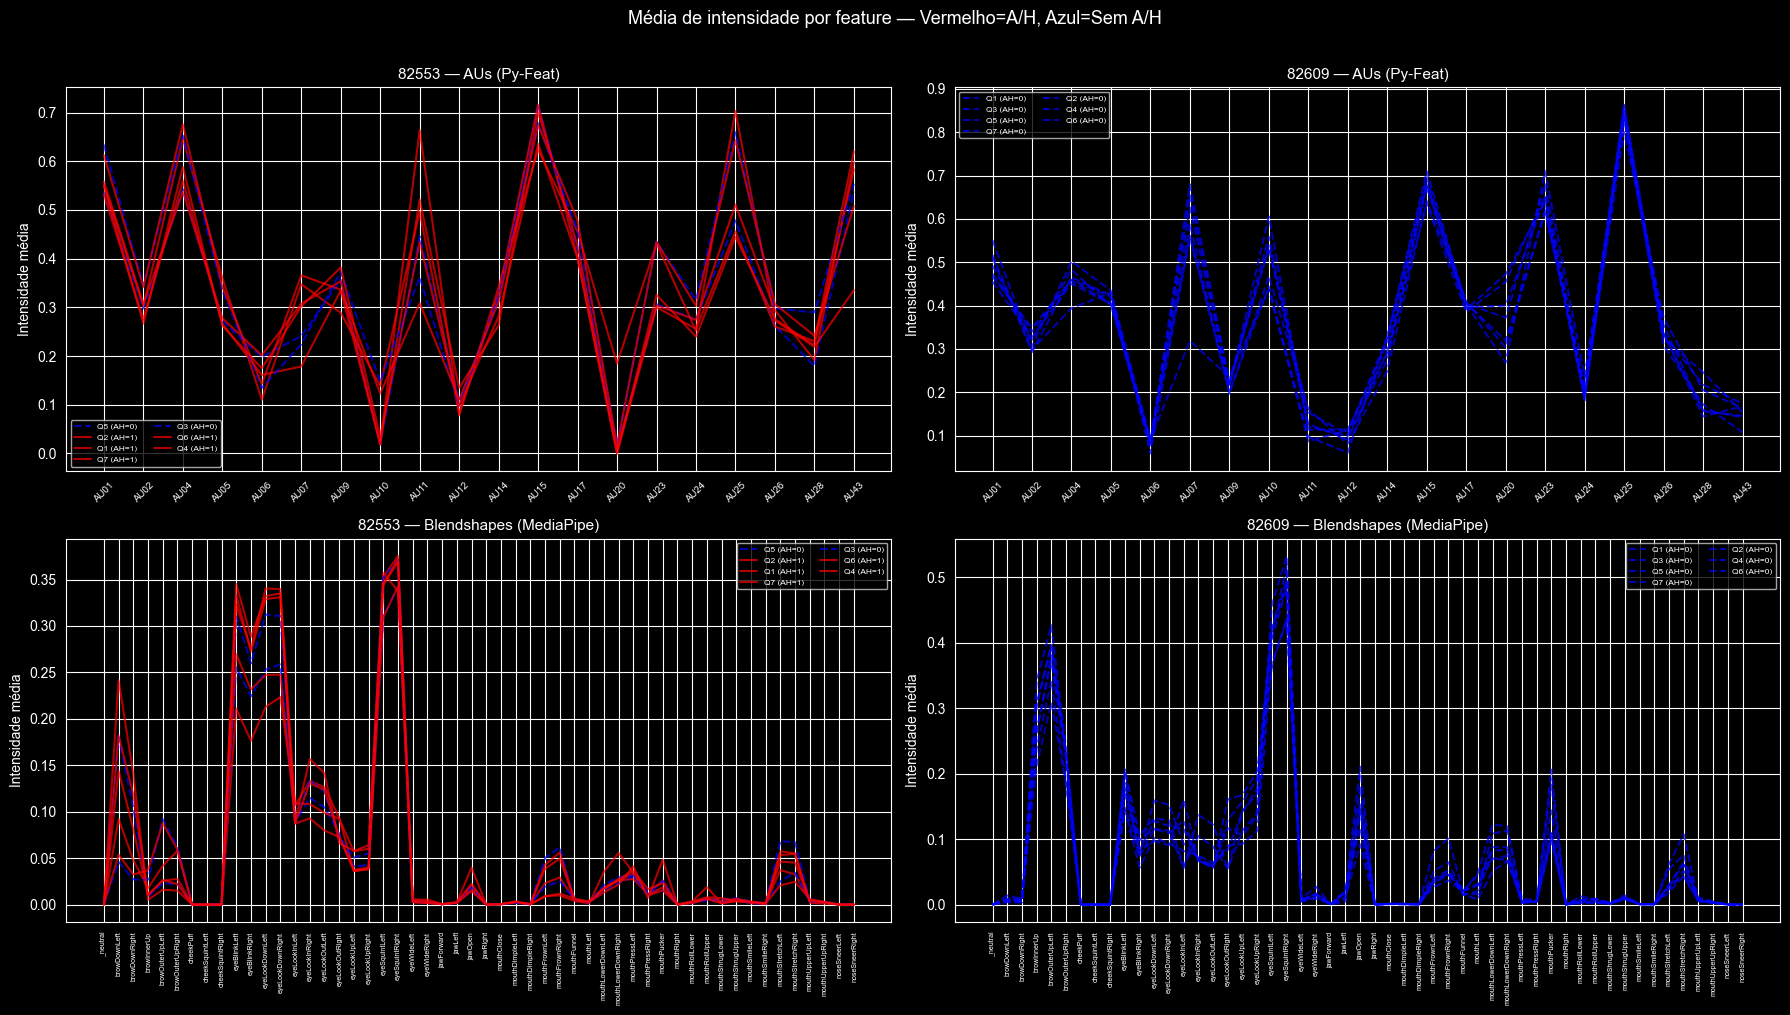

In [9]:
# CÉLULA 3: Análise 1 — Média de intensidade: AUs vs Blendshapes lado a lado

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for col, pid in enumerate(target_pids):
    # AUs
    ax_au = axes[0, col]
    for vname, d in data[pid].items():
        color = 'red' if d['label'] == 1 else 'blue'
        style = '-' if d['label'] == 1 else '--'
        mean_au = d['au'].mean(axis=0)
        ax_au.plot(mean_au, color=color, linestyle=style, alpha=0.7,
                   label=f"Q{d['q']} (AH={d['label']})")
    ax_au.set_xticks(range(len(AU_NAMES)))
    ax_au.set_xticklabels(AU_NAMES, rotation=45, fontsize=7)
    ax_au.set_ylabel('Intensidade média')
    ax_au.set_title(f'{pid} — AUs (Py-Feat)', fontsize=11)
    ax_au.legend(fontsize=6, ncol=2)
    
    # Blendshapes
    ax_bs = axes[1, col]
    for vname, d in data[pid].items():
        color = 'red' if d['label'] == 1 else 'blue'
        style = '-' if d['label'] == 1 else '--'
        mean_bs = d['bs'].mean(axis=0)
        ax_bs.plot(mean_bs, color=color, linestyle=style, alpha=0.7,
                   label=f"Q{d['q']} (AH={d['label']})")
    ax_bs.set_xticks(range(len(BS_NAMES_FULL)))
    ax_bs.set_xticklabels(BS_NAMES_FULL, rotation=90, fontsize=5)
    ax_bs.set_ylabel('Intensidade média')
    ax_bs.set_title(f'{pid} — Blendshapes (MediaPipe)', fontsize=11)
    ax_bs.legend(fontsize=6, ncol=2)

plt.suptitle('Média de intensidade por feature — Vermelho=A/H, Azul=Sem A/H', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

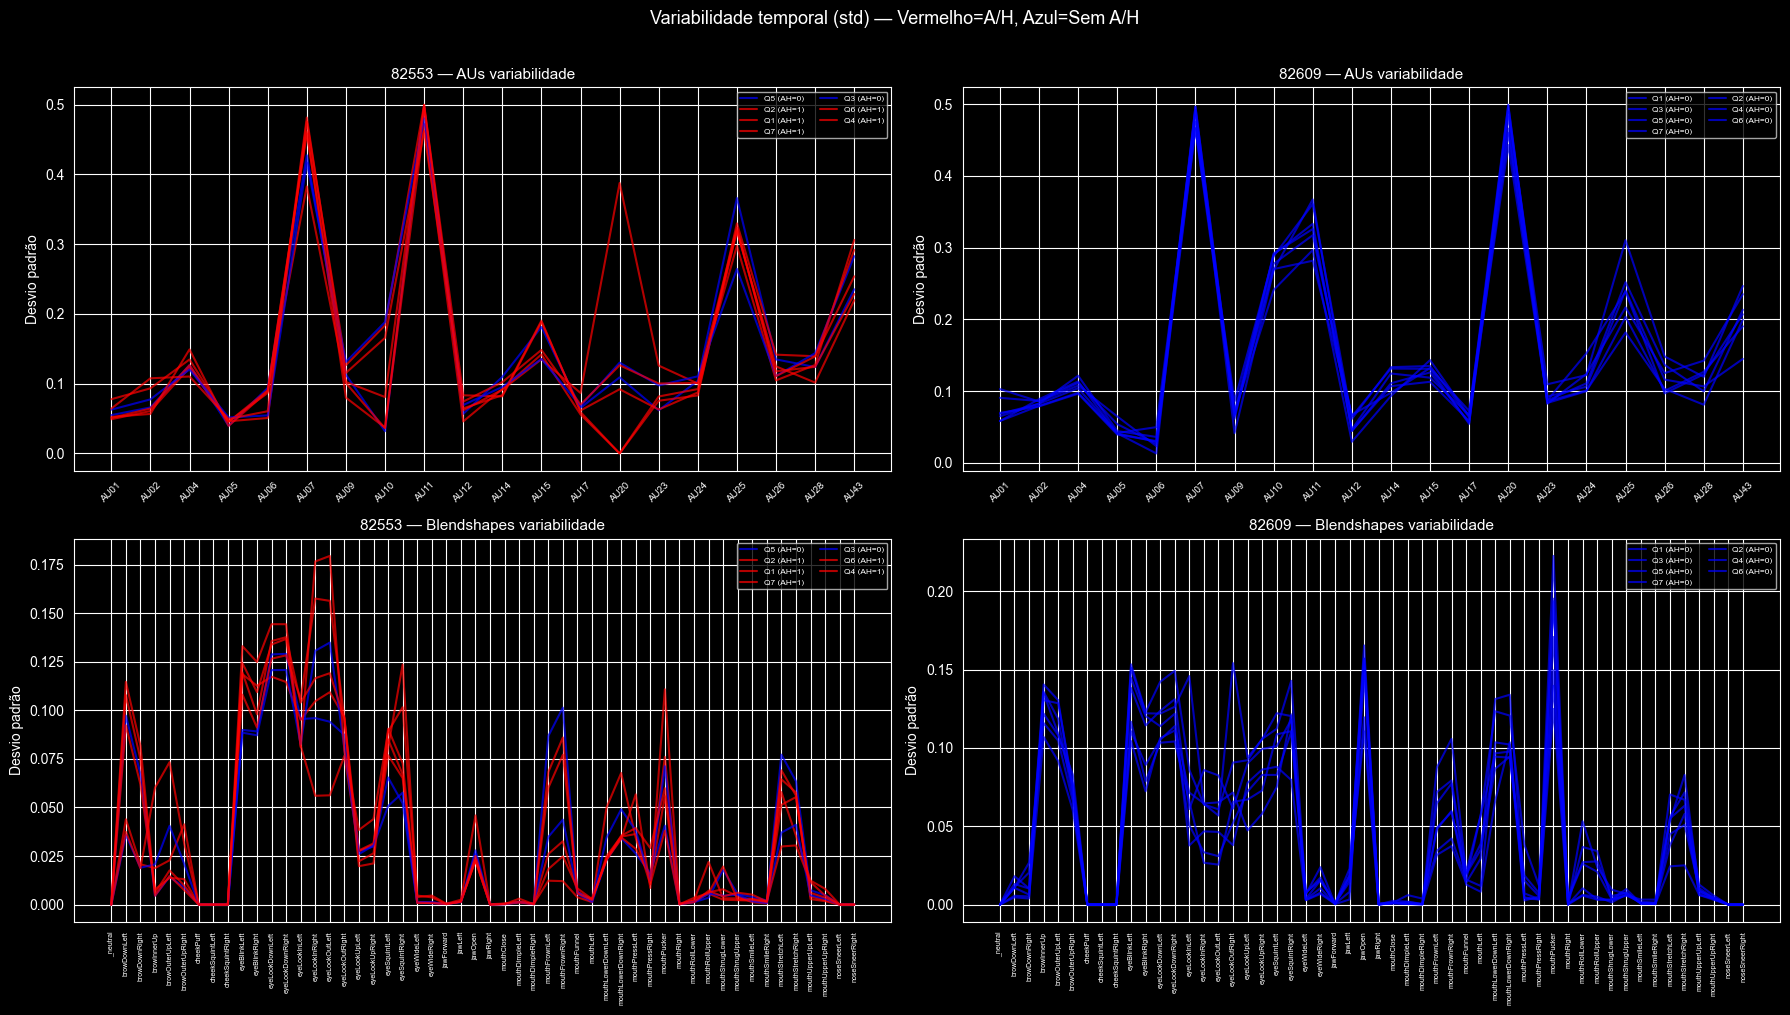

In [10]:
# CÉLULA 4: Análise 2 — Variabilidade temporal (std): AUs vs Blendshapes

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for col, pid in enumerate(target_pids):
    # AUs std
    ax_au = axes[0, col]
    for vname, d in data[pid].items():
        color = 'red' if d['label'] == 1 else 'blue'
        std_au = d['au'].std(axis=0)
        ax_au.plot(std_au, color=color, alpha=0.7,
                   label=f"Q{d['q']} (AH={d['label']})")
    ax_au.set_xticks(range(len(AU_NAMES)))
    ax_au.set_xticklabels(AU_NAMES, rotation=45, fontsize=7)
    ax_au.set_ylabel('Desvio padrão')
    ax_au.set_title(f'{pid} — AUs variabilidade', fontsize=11)
    ax_au.legend(fontsize=6, ncol=2)
    
    # Blendshapes std
    ax_bs = axes[1, col]
    for vname, d in data[pid].items():
        color = 'red' if d['label'] == 1 else 'blue'
        std_bs = d['bs'].std(axis=0)
        ax_bs.plot(std_bs, color=color, alpha=0.7,
                   label=f"Q{d['q']} (AH={d['label']})")
    ax_bs.set_xticks(range(len(BS_NAMES_FULL)))
    ax_bs.set_xticklabels(BS_NAMES_FULL, rotation=90, fontsize=5)
    ax_bs.set_ylabel('Desvio padrão')
    ax_bs.set_title(f'{pid} — Blendshapes variabilidade', fontsize=11)
    ax_bs.legend(fontsize=6, ncol=2)

plt.suptitle('Variabilidade temporal (std) — Vermelho=A/H, Azul=Sem A/H', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Sem A/H: 82553_Question_5_2024-08-22_12-12-54_Vid... (83 frames)
Com A/H: 82553_Question_2_2024-08-22_12-17-23_Vid... (141 frames)


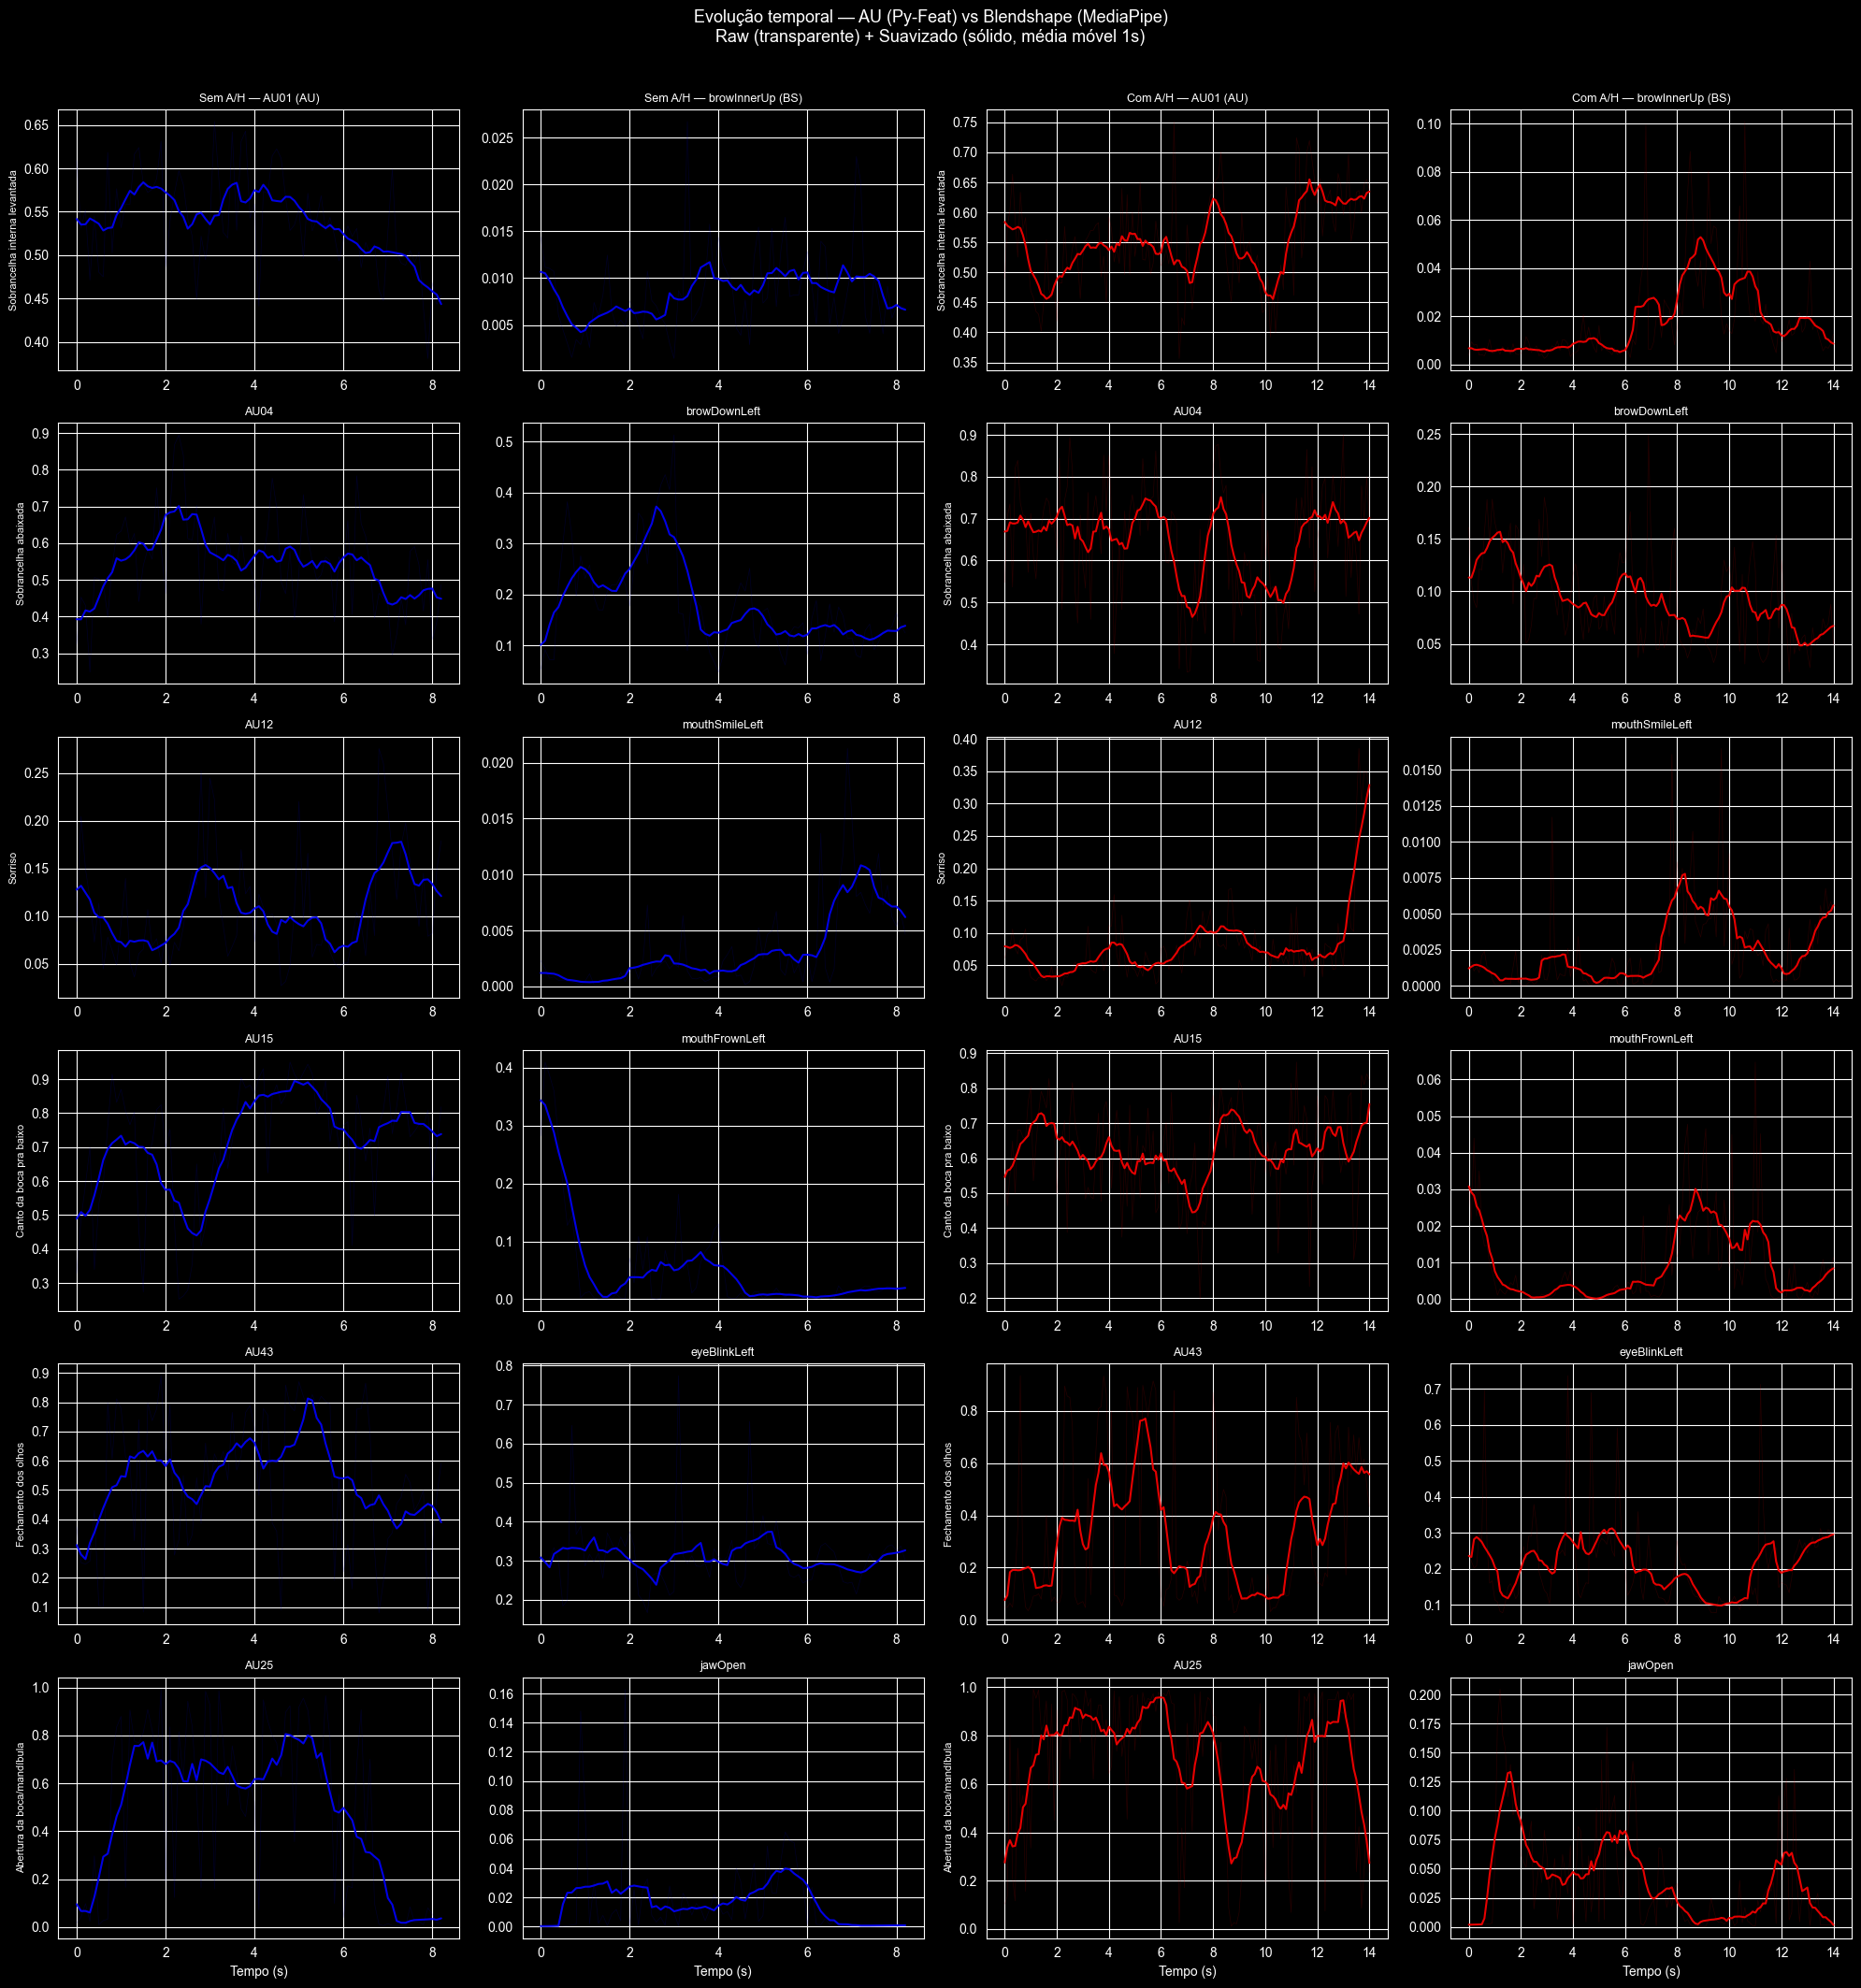

In [11]:
# CÉLULA 5: Análise 3 — Evolução temporal de features-chave: AUs vs Blendshapes
# Comparar um vídeo A/H vs não-A/H do participante 82553

# Selecionar vídeos
video_ah = None
video_no_ah = None
for vname, d in data['82553'].items():
    if d['label'] == 1 and video_ah is None:
        video_ah = (vname, d)
    if d['label'] == 0 and video_no_ah is None:
        video_no_ah = (vname, d)

print(f"Sem A/H: {video_no_ah[0][:40]}... ({len(video_no_ah[1]['au'])} frames)")
print(f"Com A/H: {video_ah[0][:40]}... ({len(video_ah[1]['au'])} frames)")

# Pares de features correspondentes: AU ↔ Blendshape
feature_pairs = [
    # (AU_idx, AU_name, BS_idx, BS_name, descrição)
    (0, 'AU01', 3, 'browInnerUp', 'Sobrancelha interna levantada'),
    (2, 'AU04', 1, 'browDownLeft', 'Sobrancelha abaixada'),
    (9, 'AU12', 44, 'mouthSmileLeft', 'Sorriso'),
    (11, 'AU15', 30, 'mouthFrownLeft', 'Canto da boca pra baixo'),
    (19, 'AU43', 9, 'eyeBlinkLeft', 'Fechamento dos olhos'),
    (16, 'AU25', 25, 'jawOpen', 'Abertura da boca/mandíbula'),
]

fig, axes = plt.subplots(len(feature_pairs), 4, figsize=(20, 3.5 * len(feature_pairs)))
fig.suptitle('Evolução temporal — AU (Py-Feat) vs Blendshape (MediaPipe)\n'
             'Raw (transparente) + Suavizado (sólido, média móvel 1s)', 
             fontsize=13, y=1.01)

for row, (au_idx, au_name, bs_idx, bs_name, desc) in enumerate(feature_pairs):
    for col_offset, (vname, vdata, color, title_prefix) in enumerate([
        (video_no_ah[0], video_no_ah[1], 'blue', 'Sem A/H'),
        (video_ah[0], video_ah[1], 'red', 'Com A/H')
    ]):
        # AU
        ax_au = axes[row, col_offset * 2]
        time_axis = np.arange(len(vdata['au'])) / EFFECTIVE_FPS
        raw = vdata['au'][:, au_idx]
        smooth = uniform_filter1d(raw, size=SMOOTH_WINDOW)
        ax_au.plot(time_axis, raw, color=color, alpha=0.15, linewidth=0.5)
        ax_au.plot(time_axis, smooth, color=color, alpha=0.9, linewidth=1.5)
        ax_au.set_ylabel(f'{desc}', fontsize=8)
        if row == 0:
            ax_au.set_title(f'{title_prefix} — {au_name} (AU)', fontsize=9)
        else:
            ax_au.set_title(f'{au_name}', fontsize=9)
        if row == len(feature_pairs) - 1:
            ax_au.set_xlabel('Tempo (s)')
        
        # Blendshape
        ax_bs = axes[row, col_offset * 2 + 1]
        raw_bs = vdata['bs'][:, bs_idx]
        smooth_bs = uniform_filter1d(raw_bs, size=SMOOTH_WINDOW)
        ax_bs.plot(time_axis, raw_bs, color=color, alpha=0.15, linewidth=0.5)
        ax_bs.plot(time_axis, smooth_bs, color=color, alpha=0.9, linewidth=1.5)
        if row == 0:
            ax_bs.set_title(f'{title_prefix} — {bs_name} (BS)', fontsize=9)
        else:
            ax_bs.set_title(f'{bs_name}', fontsize=9)
        if row == len(feature_pairs) - 1:
            ax_bs.set_xlabel('Tempo (s)')

plt.tight_layout()
plt.show()

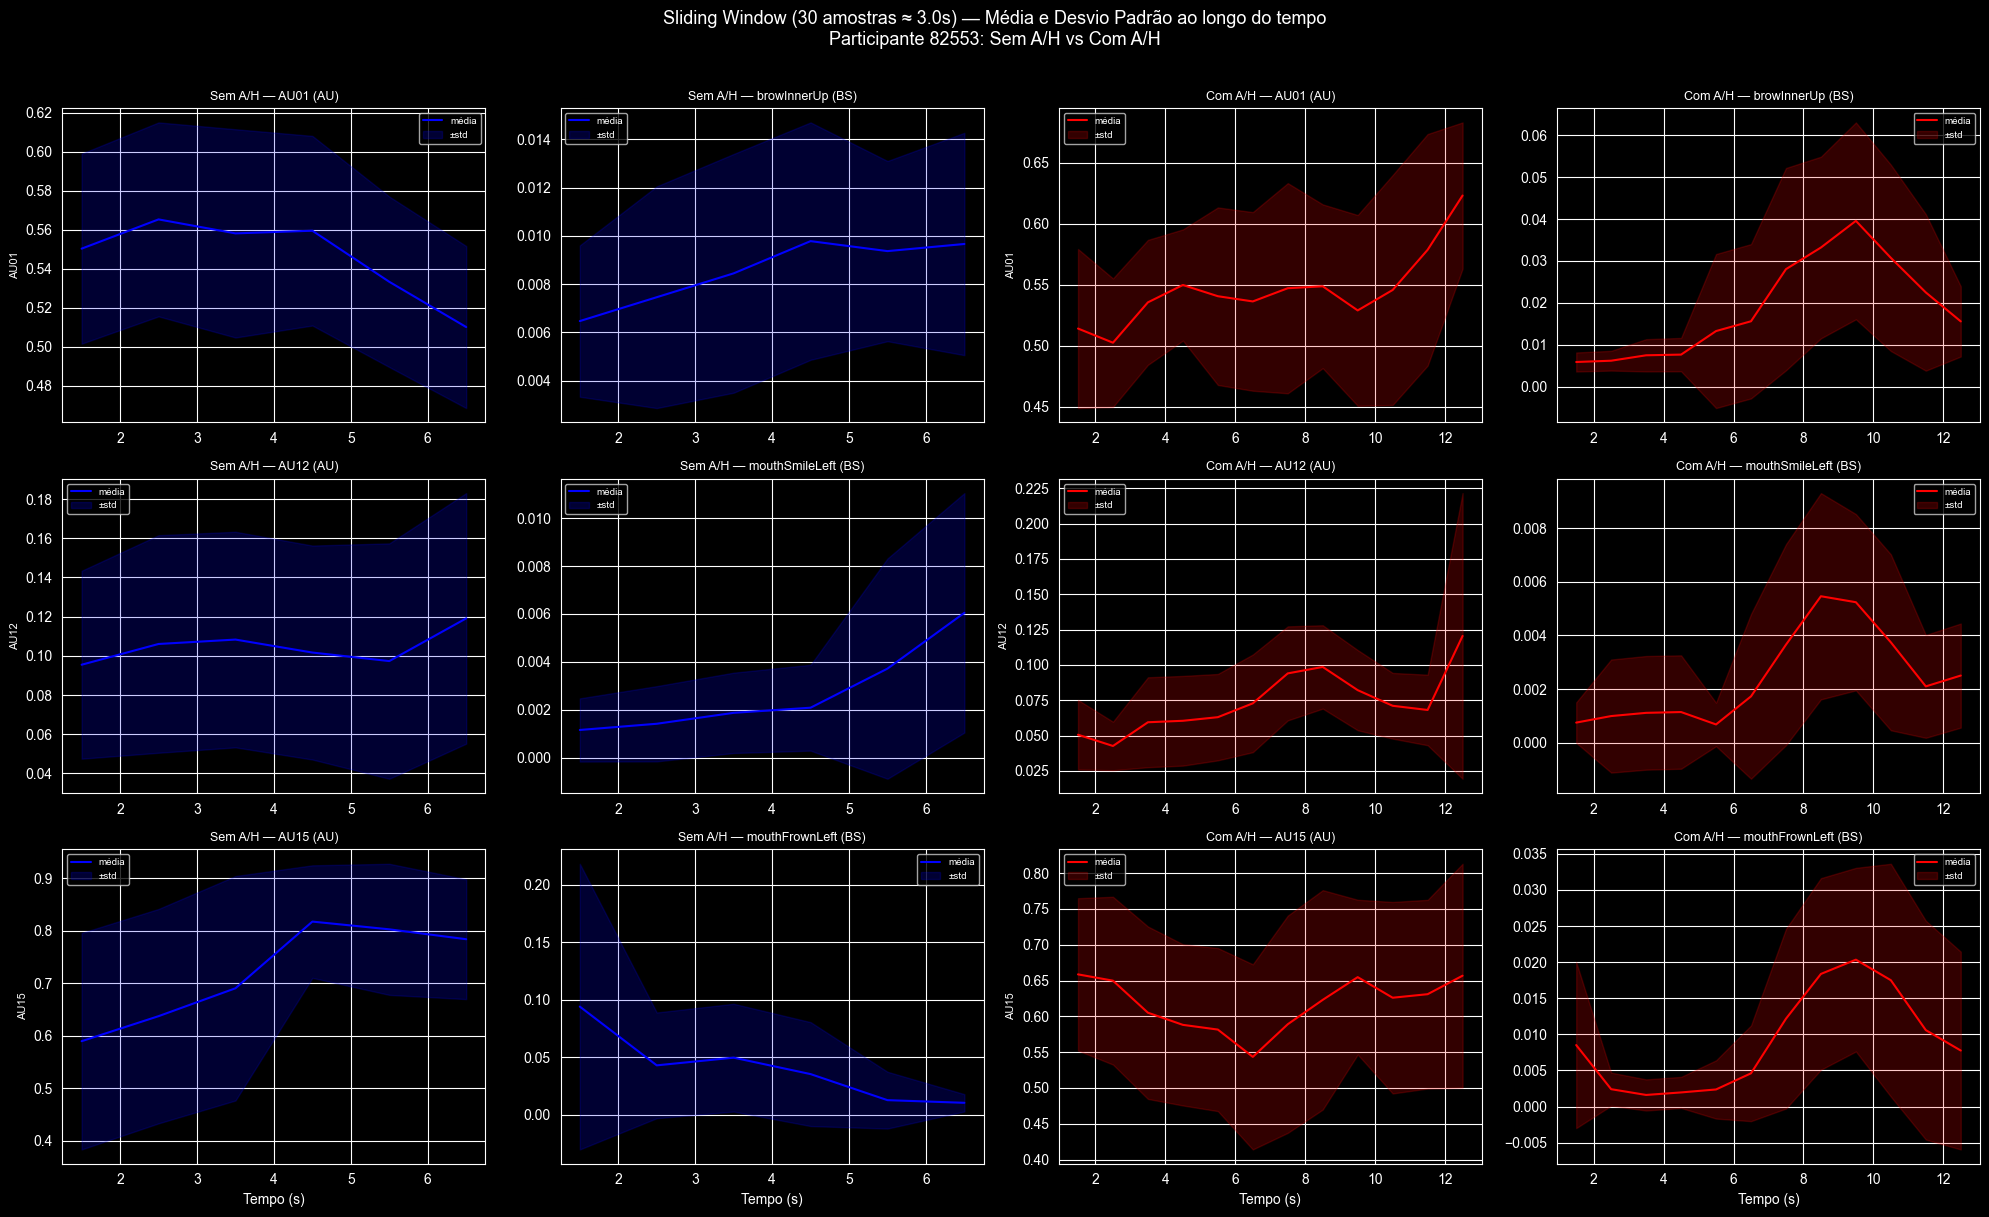

In [12]:
# CÉLULA 6: Análise 4 — Sliding window statistics ao longo do tempo
# Mostra como média e std mudam dentro de janelas temporais

WINDOW_SIZE = 30  # 30 amostras = ~3s a 10fps
WINDOW_STEP = 10  # overlap de ~2s

def compute_windowed_stats(signal, window_size, step):
    """Calcula média e std em janelas deslizantes."""
    means, stds, slopes, centers = [], [], [], []
    for start in range(0, len(signal) - window_size + 1, step):
        window = signal[start:start + window_size]
        means.append(np.mean(window))
        stds.append(np.std(window))
        # Slope (tendência na janela)
        x = np.arange(window_size)
        slopes.append(np.polyfit(x, window, 1)[0])
        centers.append((start + window_size / 2) / EFFECTIVE_FPS)
    return np.array(centers), np.array(means), np.array(stds), np.array(slopes)


# Features pra análise
key_features = [
    ('AU01', 0, 'au', 'browInnerUp', 3, 'bs'),
    ('AU12', 9, 'au', 'mouthSmileLeft', 44, 'bs'),
    ('AU15', 11, 'au', 'mouthFrownLeft', 30, 'bs'),
]

fig, axes = plt.subplots(len(key_features), 4, figsize=(20, 4 * len(key_features)))
fig.suptitle(f'Sliding Window ({WINDOW_SIZE} amostras ≈ {WINDOW_SIZE/EFFECTIVE_FPS:.1f}s) — '
             f'Média e Desvio Padrão ao longo do tempo\n'
             f'Participante 82553: Sem A/H vs Com A/H', fontsize=13, y=1.01)

for row, (au_name, au_idx, _, bs_name, bs_idx, _) in enumerate(key_features):
    for is_ah, (vname, vdata) in enumerate([(video_no_ah[0], video_no_ah[1]),
                                             (video_ah[0], video_ah[1])]):
        color = 'red' if is_ah else 'blue'
        ah_label = 'Com A/H' if is_ah else 'Sem A/H'
        
        # AU windowed
        ax = axes[row, is_ah * 2]
        centers, means, stds, slopes = compute_windowed_stats(
            vdata['au'][:, au_idx], WINDOW_SIZE, WINDOW_STEP)
        ax.plot(centers, means, color=color, linewidth=1.5, label='média')
        ax.fill_between(centers, means - stds, means + stds, color=color, alpha=0.2, label='±std')
        ax.set_title(f'{ah_label} — {au_name} (AU)', fontsize=9)
        ax.set_ylabel(f'{au_name}', fontsize=8)
        ax.legend(fontsize=7)
        if row == len(key_features) - 1:
            ax.set_xlabel('Tempo (s)')
        
        # BS windowed
        ax = axes[row, is_ah * 2 + 1]
        centers, means, stds, slopes = compute_windowed_stats(
            vdata['bs'][:, bs_idx], WINDOW_SIZE, WINDOW_STEP)
        ax.plot(centers, means, color=color, linewidth=1.5, label='média')
        ax.fill_between(centers, means - stds, means + stds, color=color, alpha=0.2, label='±std')
        ax.set_title(f'{ah_label} — {bs_name} (BS)', fontsize=9)
        ax.legend(fontsize=7)
        if row == len(key_features) - 1:
            ax.set_xlabel('Tempo (s)')

plt.tight_layout()
plt.show()

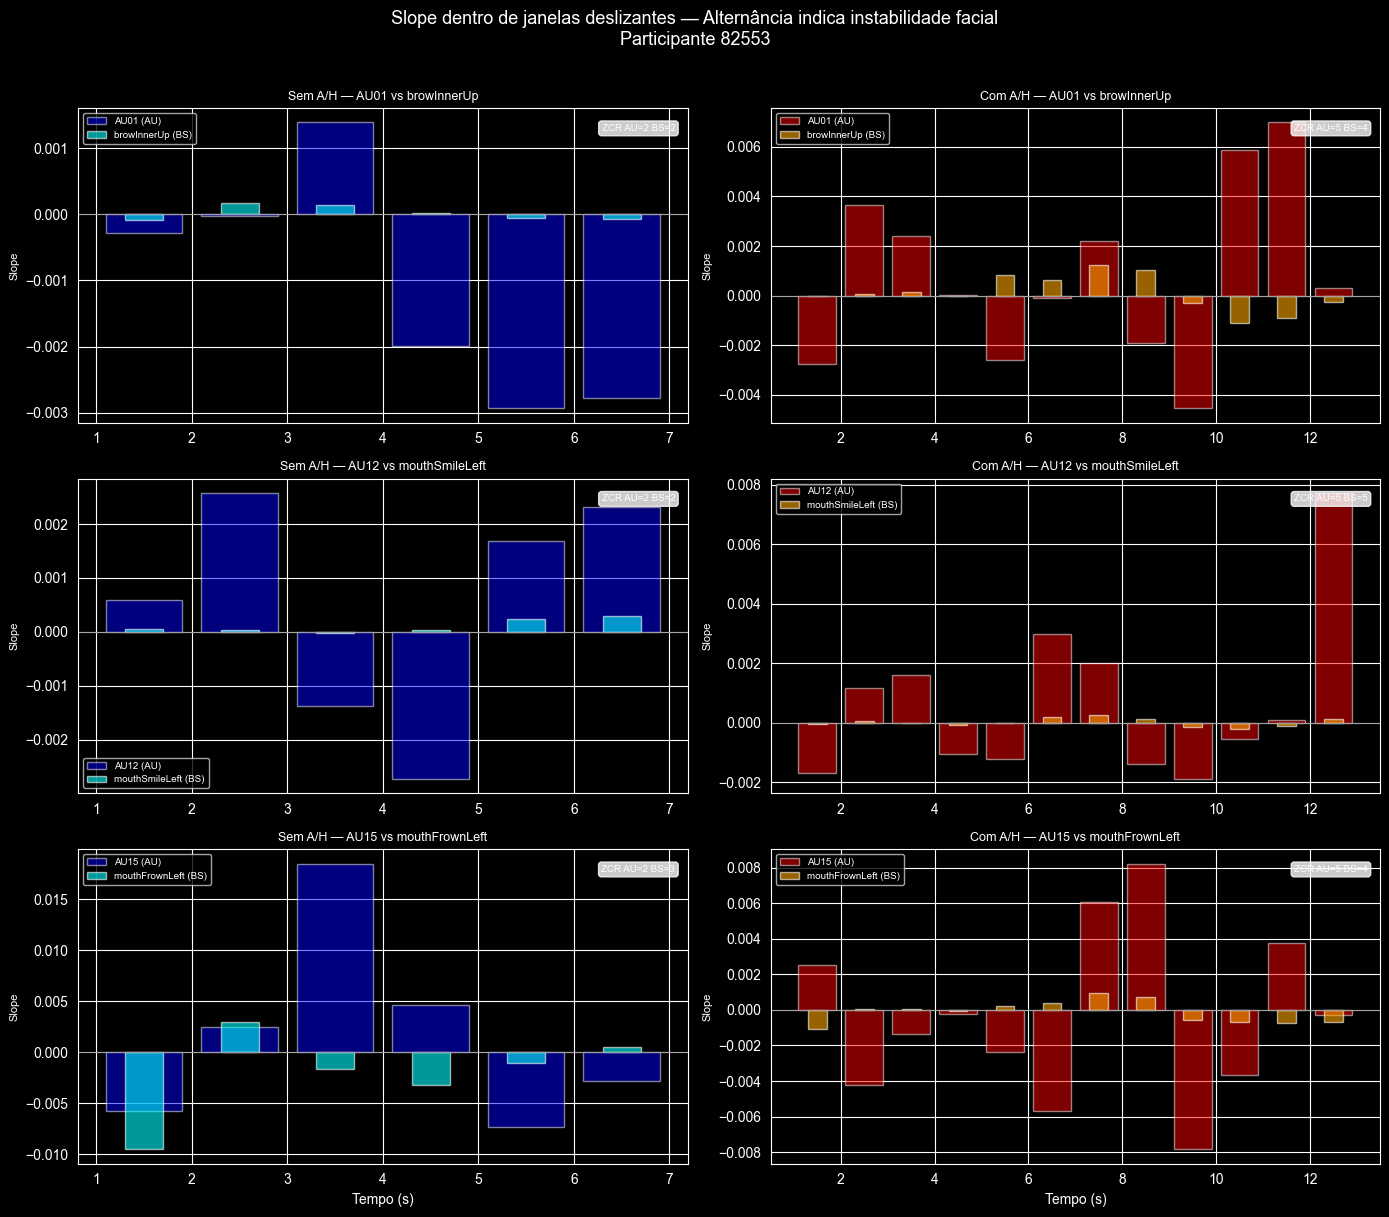

In [13]:
# CÉLULA 7: Análise 5 — Slope (tendência) dentro das janelas
# Slopes positivos/negativos indicam mudanças de expressão
# A/H deveria ter mais alternâncias de slope (oscilação)

fig, axes = plt.subplots(len(key_features), 2, figsize=(14, 4 * len(key_features)))
fig.suptitle(f'Slope dentro de janelas deslizantes — Alternância indica instabilidade facial\n'
             f'Participante 82553', fontsize=13, y=1.01)

for row, (au_name, au_idx, _, bs_name, bs_idx, _) in enumerate(key_features):
    for is_ah, (vname, vdata) in enumerate([(video_no_ah[0], video_no_ah[1]),
                                             (video_ah[0], video_ah[1])]):
        color = 'red' if is_ah else 'blue'
        ah_label = 'Com A/H' if is_ah else 'Sem A/H'
        ax = axes[row, is_ah]
        
        # AU slope
        centers, _, _, slopes_au = compute_windowed_stats(
            vdata['au'][:, au_idx], WINDOW_SIZE, WINDOW_STEP)
        ax.bar(centers, slopes_au, width=WINDOW_STEP/EFFECTIVE_FPS * 0.8,
               color=color, alpha=0.5, label=f'{au_name} (AU)')
        
        # BS slope
        centers, _, _, slopes_bs = compute_windowed_stats(
            vdata['bs'][:, bs_idx], WINDOW_SIZE, WINDOW_STEP)
        ax.bar(centers, slopes_bs, width=WINDOW_STEP/EFFECTIVE_FPS * 0.4,
               color='orange' if is_ah else 'cyan', alpha=0.6, label=f'{bs_name} (BS)')
        
        ax.axhline(0, color='gray', linewidth=0.5)
        ax.set_title(f'{ah_label} — {au_name} vs {bs_name}', fontsize=9)
        ax.set_ylabel('Slope', fontsize=8)
        ax.legend(fontsize=7)
        if row == len(key_features) - 1:
            ax.set_xlabel('Tempo (s)')

        # Contar zero-crossings do slope (alternância de direção)
        zcr_au = np.sum(np.abs(np.diff(np.sign(slopes_au))) > 0)
        zcr_bs = np.sum(np.abs(np.diff(np.sign(slopes_bs))) > 0)
        ax.text(0.98, 0.95, f'ZCR AU={zcr_au} BS={zcr_bs}',
                transform=ax.transAxes, fontsize=7, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

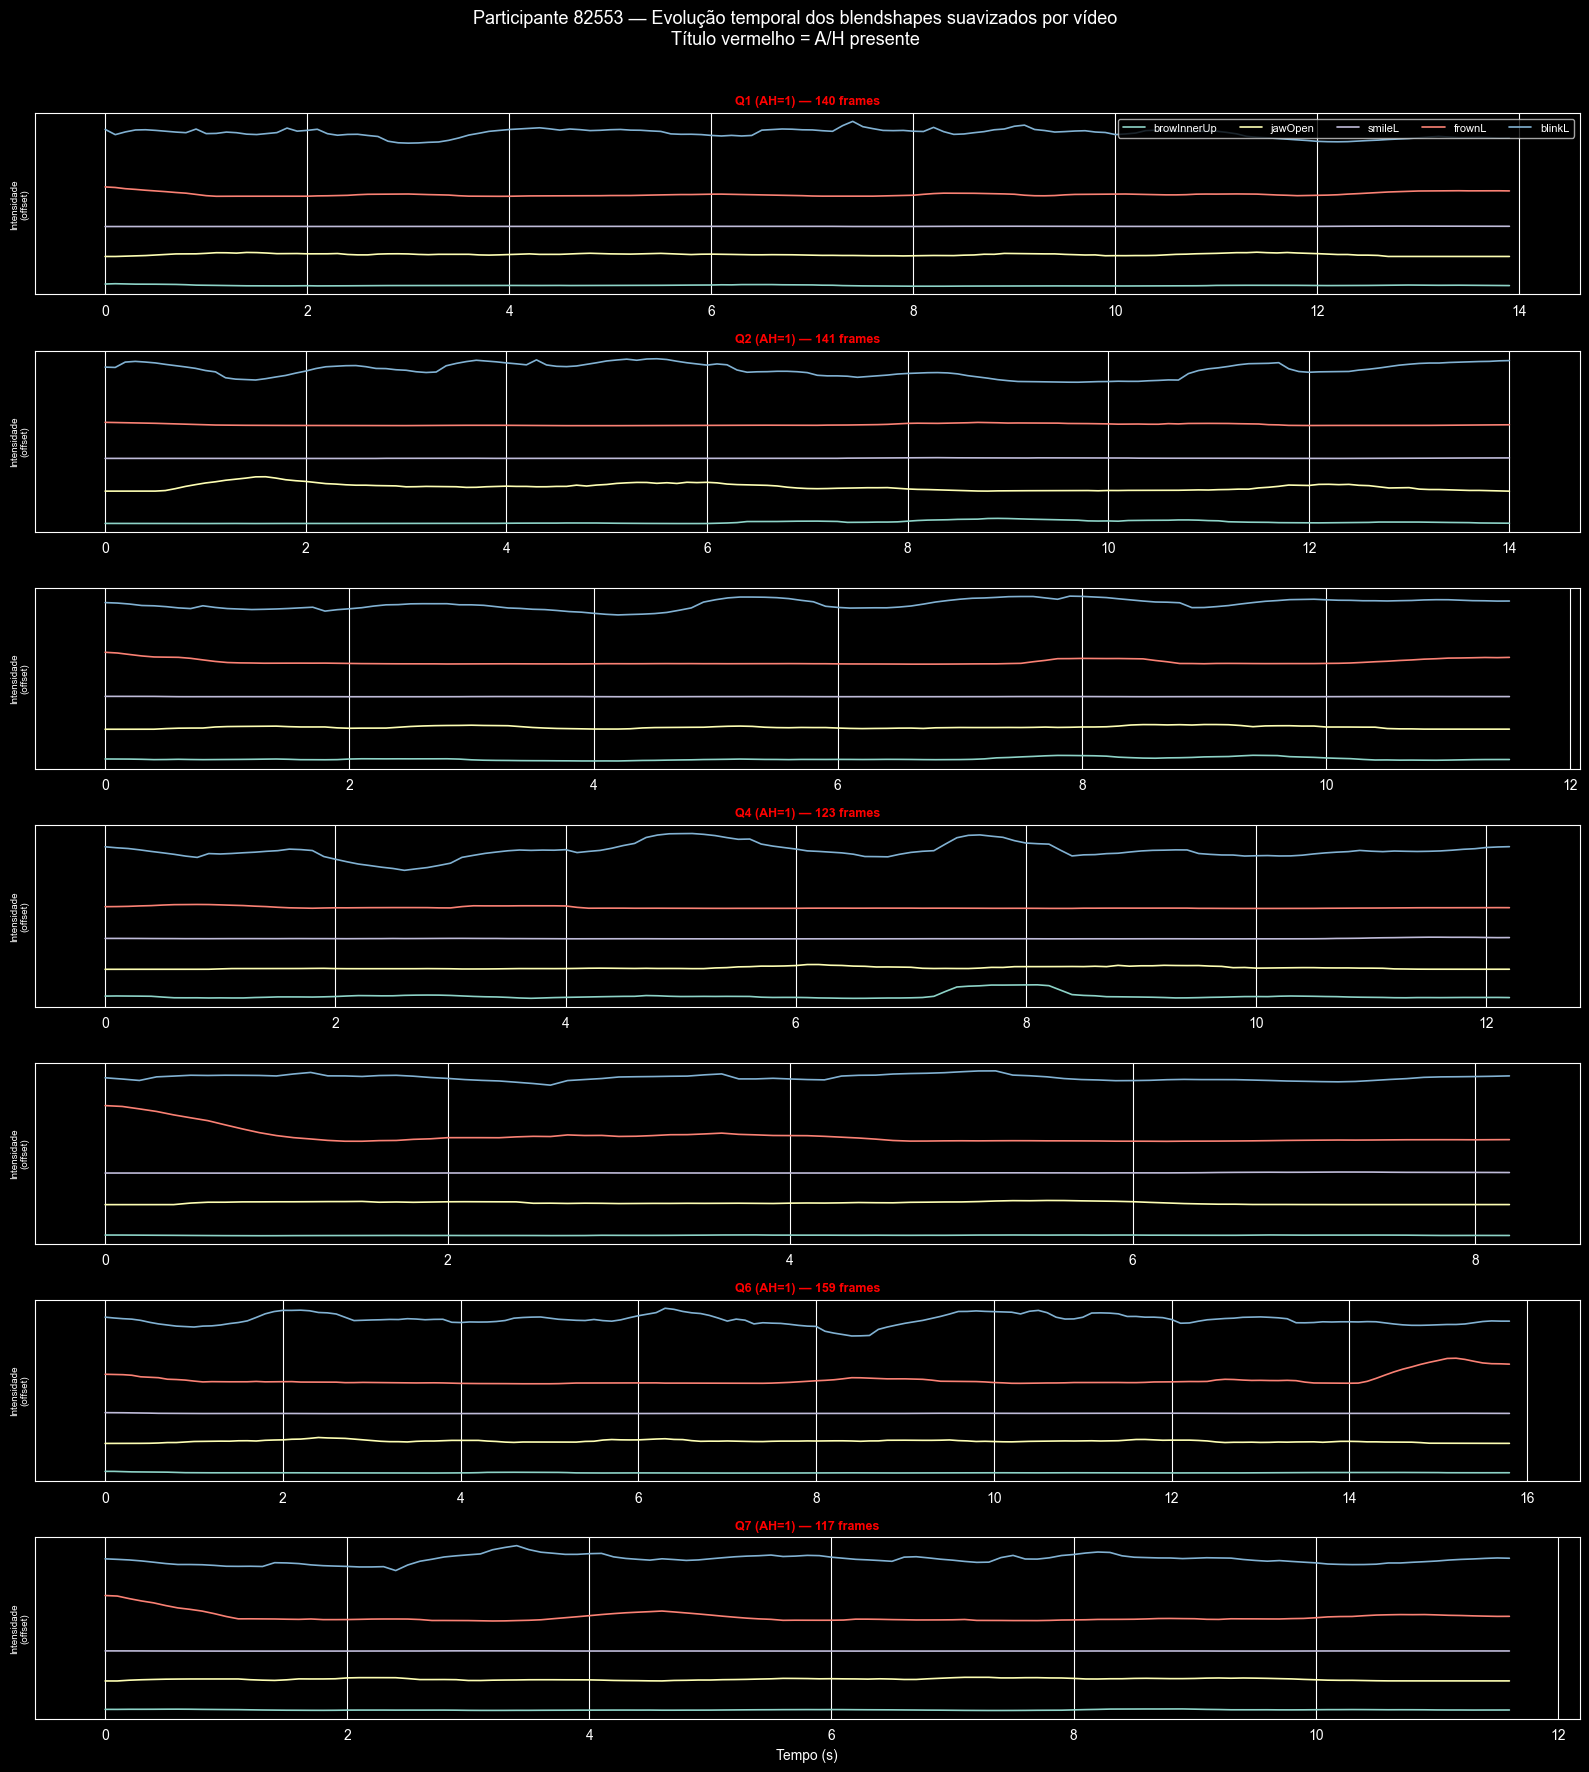

In [14]:
# CÉLULA 8: Análise 6 — Comparar TODOS os 7 vídeos do participante 82553
# Heatmap temporal: intensidade das features ao longo do tempo por vídeo

# Selecionar 5 blendshapes mais discriminativos visualmente
key_bs_indices = [3, 25, 44, 30, 9]  # browInnerUp, jawOpen, smileL, frownL, blinkL
key_bs_names = ['browInnerUp', 'jawOpen', 'smileL', 'frownL', 'blinkL']

videos_sorted = sorted(data['82553'].items(), key=lambda x: x[1]['q'])

fig, axes = plt.subplots(len(videos_sorted), 1, figsize=(16, 2.5 * len(videos_sorted)),
                         sharex=False)
fig.suptitle('Participante 82553 — Evolução temporal dos blendshapes suavizados por vídeo\n'
             'Título vermelho = A/H presente', fontsize=13, y=1.01)

for i, (vname, vdata) in enumerate(videos_sorted):
    ax = axes[i]
    time_axis = np.arange(len(vdata['bs'])) / EFFECTIVE_FPS
    
    for j, (bs_idx, bs_name) in enumerate(zip(key_bs_indices, key_bs_names)):
        smooth = uniform_filter1d(vdata['bs'][:, bs_idx], size=SMOOTH_WINDOW)
        ax.plot(time_axis, smooth + j * 0.3, linewidth=1.2,
                label=bs_name if i == 0 else None)
    
    title_color = 'red' if vdata['label'] == 1 else 'black'
    ax.set_title(f"Q{vdata['q']} (AH={vdata['label']}) — {len(vdata['bs'])} frames",
                 fontsize=9, color=title_color, fontweight='bold' if vdata['label'] == 1 else 'normal')
    ax.set_ylabel('Intensidade\n(offset)', fontsize=7)
    ax.set_yticks([])
    if i == len(videos_sorted) - 1:
        ax.set_xlabel('Tempo (s)')

axes[0].legend(fontsize=8, ncol=5, loc='upper right')
plt.tight_layout()
plt.show()

In [15]:
# CÉLULA 9: Análise 7 — Stats comparativas numéricas: AU vs BS

print("=" * 80)
print("ESTATÍSTICAS COMPARATIVAS — Participante 82553")
print("=" * 80)

# Calcular stats agregadas por classe
for feat_type, feat_name, indices, names in [
    ('au', 'AUs (Py-Feat)', [0, 2, 9, 11, 19], ['AU01', 'AU04', 'AU12', 'AU15', 'AU43']),
    ('bs', 'Blendshapes (MediaPipe)', [3, 1, 44, 30, 9], ['browInnerUp', 'browDownL', 'smileL', 'frownL', 'blinkL'])
]:
    print(f"\n--- {feat_name} ---")
    print(f"{'Feature':<20} {'Métrica':<10} {'A/H':>8} {'Sem A/H':>10} {'Diff':>8}")
    print("-" * 60)
    
    for feat_idx, feat_label in zip(indices, names):
        ah_vals, no_ah_vals = [], []
        for vname, d in data['82553'].items():
            signal = d[feat_type][:, feat_idx]
            if d['label'] == 1:
                ah_vals.append(signal)
            else:
                no_ah_vals.append(signal)
        
        # Concatenar todos os frames por classe
        ah_all = np.concatenate(ah_vals) if ah_vals else np.array([])
        no_ah_all = np.concatenate(no_ah_vals) if no_ah_vals else np.array([])
        
        for metric, func in [('mean', np.mean), ('std', np.std)]:
            v_ah = func(ah_all) if len(ah_all) > 0 else 0
            v_no = func(no_ah_all) if len(no_ah_all) > 0 else 0
            diff = v_ah - v_no
            print(f"{feat_label:<20} {metric:<10} {v_ah:>8.4f} {v_no:>10.4f} {diff:>+8.4f}")

# Zero-crossing rate do slope (instabilidade)
print(f"\n--- Zero-Crossing Rate do Slope (instabilidade facial) ---")
print(f"{'Feature':<20} {'Tipo':<5} {'A/H':>8} {'Sem A/H':>10}")
print("-" * 50)

for feat_type, indices, names in [
    ('au', [0, 9, 11], ['AU01', 'AU12', 'AU15']),
    ('bs', [3, 44, 30], ['browInnerUp', 'smileL', 'frownL'])
]:
    for feat_idx, feat_label in zip(indices, names):
        zcr_ah, zcr_no = [], []
        for vname, d in data['82553'].items():
            signal = d[feat_type][:, feat_idx]
            if len(signal) > WINDOW_SIZE:
                _, _, _, slopes = compute_windowed_stats(signal, WINDOW_SIZE, WINDOW_STEP)
                zcr = np.sum(np.abs(np.diff(np.sign(slopes))) > 0) / len(slopes) if len(slopes) > 1 else 0
                if d['label'] == 1:
                    zcr_ah.append(zcr)
                else:
                    zcr_no.append(zcr)
        
        mean_ah = np.mean(zcr_ah) if zcr_ah else 0
        mean_no = np.mean(zcr_no) if zcr_no else 0
        marker = '***' if abs(mean_ah - mean_no) > 0.1 else ''
        print(f"{feat_label:<20} {feat_type:<5} {mean_ah:>8.3f} {mean_no:>10.3f} {marker}")

ESTATÍSTICAS COMPARATIVAS — Participante 82553

--- AUs (Py-Feat) ---
Feature              Métrica         A/H    Sem A/H     Diff
------------------------------------------------------------
AU01                 mean         0.5590     0.5939  -0.0349
AU01                 std          0.0655     0.0764  -0.0109
AU04                 mean         0.6018     0.6069  -0.0051
AU04                 std          0.1399     0.1343  +0.0056
AU12                 mean         0.0990     0.1021  -0.0031
AU12                 std          0.0692     0.0645  +0.0047
AU15                 mean         0.6680     0.6938  -0.0259
AU15                 std          0.1667     0.1574  +0.0093
AU43                 mean         0.5295     0.5472  -0.0178
AU43                 std          0.2827     0.2643  +0.0184

--- Blendshapes (MediaPipe) ---
Feature              Métrica         A/H    Sem A/H     Diff
------------------------------------------------------------
browInnerUp          mean         0.0154   